# EDA — Inventario del almacén ALDIMI
**Machine Learning 1ACC0057 · UPC · Grupo 2**

Análisis exploratorio de los datos **reales del almacén del Albergue Divina Misericordia**:
el consolidado por artículo (`aldimi_dataset_completo.csv`), el histórico semanal
(`aldimi_dataset_semanal.csv`) y el catálogo maestro de productos
(`catalogo_productos.csv`), que aporta el **nombre visible**, la **unidad de medida
estándar** y la **categoría general de negocio** de cada código.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

RUTA = 'data/processed'
df_art = pd.read_csv(f'{RUTA}/aldimi_dataset_completo.csv')
df_sem = pd.read_csv(f'{RUTA}/aldimi_dataset_semanal.csv')
catalogo = pd.read_csv(f'{RUTA}/catalogo_productos.csv')
df_art.shape, df_sem.shape, catalogo.shape

((1679, 18), (5460, 16), (1678, 8))

## 1. Estructura y calidad de los datos

In [2]:
df_art.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   codigo_articulo        1679 non-null   object 
 1   categoria              1679 non-null   object 
 2   existencias_iniciales  1679 non-null   float64
 3   total_entradas         1679 non-null   float64
 4   total_salidas          1679 non-null   float64
 5   existencias_actuales   1679 non-null   float64
 6   tasa_rotacion          1679 non-null   float64
 7   tiene_precio           1679 non-null   int64  
 8   tiene_proveedor        1679 non-null   int64  
 9   frecuencia_salidas     1679 non-null   int64  
 10  frecuencia_entradas    1679 non-null   int64  
 11  necesita_reposicion    1679 non-null   int64  
 12  origen                 1679 non-null   object 
 13  nombre_producto        1679 non-null   object 
 14  presentacion           405 non-null    object 
 15  unid

In [3]:
df_art.head(10)

,codigo_articulo,categoria,existencias_iniciales,total_entradas,total_salidas,existencias_actuales,tasa_rotacion,tiene_precio,tiene_proveedor,frecuencia_salidas,frecuencia_entradas,necesita_reposicion,origen,nombre_producto,presentacion,unidad_medida,categoria_general,es_producto
0,SINT0508,Azucar,12.0,5.0,2.40,14.40,0.1429,0,0,4,2,0,sintetico,Registro técnico (sin descripción),NaN,kg,Abarrotes,False
1,0488PE,Pescado,0.0,0.0,0.00,0.00,0.0000,0,0,0,0,1,real,Registro técnico (sin descripción),NaN,kg,Cárnicos y pescados,False
2,0206AZ,Azucar,0.0,0.0,0.00,0.00,0.0000,0,0,0,0,1,real,Registro técnico (sin descripción),NaN,kg,Abarrotes,False
3,0051ME,Menestras,12.0,8.0,6.00,14.00,0.3000,0,1,1,3,0,real,Pallar 500 gr,500 gr,kg,Menestras,True
4,SINT0922,Snacks,18.0,6.0,4.68,19.32,0.1950,0,0,2,6,0,sintetico,Registro técnico (sin descripción),NaN,paquete,Snacks y dulces,False
5,0487PE,Pescado,0.0,0.0,0.00,0.00,0.0000,0,0,0,0,1,real,Registro técnico (sin descripción),NaN,kg,Cárnicos y pescados,False
6,SINT0214,Aves,4.0,0.0,0.18,3.57,0.0481,0,0,6,2,1,sintetico,Registro técnico (sin descripción),NaN,kg,Avícolas,False
7,SINT0940,Infusion,11.0,9.0,4.07,15.93,0.2035,0,0,3,3,0,sintetico,Registro técnico (sin descripción),NaN,caja,Bebidas e infusiones,False
8,SINT0980,Limpieza,20.0,7.0,1.70,25.30,0.0630,0,0,4,3,0,sintetico,Registro técnico (sin descripción),NaN,unidad,Limpieza e higiene,False
9,0524CE,Cerdo,7.0,5.0,0.00,12.00,0.0000,0,1,0,2,0,real,Cerdo saborizado,NaN,kg,Cárnicos y pescados,True


In [4]:
print('Nulos por columna (artículos):')
print(df_art.isnull().sum())
print('\nDuplicados:', df_art.duplicated(subset='codigo_articulo').sum())
print('Stock negativo:', (df_art['existencias_actuales'] < 0).sum())

Nulos por columna (artículos):
codigo_articulo             0
categoria                   0
existencias_iniciales       0
total_entradas              0
total_salidas               0
existencias_actuales        0
tasa_rotacion               0
tiene_precio                0
tiene_proveedor             0
frecuencia_salidas          0
frecuencia_entradas         0
necesita_reposicion         0
origen                      0
nombre_producto             0
presentacion             1274
unidad_medida               0
categoria_general           0
es_producto                 0
dtype: int64

Duplicados: 1
Stock negativo: 319


## 2. Productos reales vs. registros técnicos

El catálogo separa los **productos reales** (con nombre y unidad, visibles en la app)
de los **registros técnicos**: códigos sintéticos `SINT####` generados para entrenar
los modelos y códigos del kardex sin descripción.

In [5]:
resumen = catalogo.groupby(['origen', 'es_producto']).size().rename('códigos').reset_index()
print(resumen.to_string(index=False))
print(f"\nProductos visibles en la app: {catalogo['es_producto'].sum()}")
print(f"Registros técnicos (solo entrenamiento): {(~catalogo['es_producto'].astype(bool)).sum()}")

   origen  es_producto  códigos
     real        False       76
     real         True      602
sintetico        False     1000

Productos visibles en la app: 602
Registros técnicos (solo entrenamiento): 1076


## 3. Unidad de medida estándar por tipo de producto

In [6]:
(catalogo[catalogo['es_producto'].astype(bool)]
 .groupby(['categoria_general', 'unidad_medida']).size()
 .unstack(fill_value=0))

unidad_medida,caja,kg,lata,litro,paquete,unidad
categoria_general,,,,,,
Abarrotes,0,20,0,22,0,80
Avícolas,0,24,0,0,0,4
Bebidas e infusiones,30,0,0,0,0,20
Cereales y farináceos,0,78,0,0,0,0
Conservas,0,0,28,0,0,0
Cárnicos y pescados,0,45,0,0,3,0
Limpieza e higiene,0,0,0,0,0,103
Lácteos,0,0,23,0,0,0
Menestras,0,87,0,0,0,0


## 4. Productos por categoría general de negocio

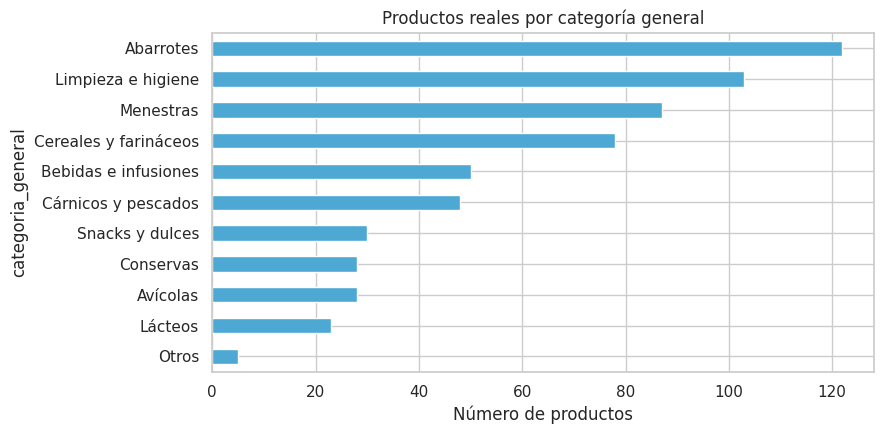

In [7]:
prod = catalogo[catalogo['es_producto'].astype(bool)]
conteo = prod['categoria_general'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
conteo.sort_values().plot.barh(ax=ax, color='#4da9d4')
ax.set_xlabel('Número de productos')
ax.set_title('Productos reales por categoría general')
plt.tight_layout(); plt.show()

## 5. Estadísticos del inventario (solo productos reales)

In [8]:
df_prod = df_art[df_art['es_producto'].astype(bool)].copy()
cols = ['existencias_iniciales', 'total_entradas', 'total_salidas',
        'existencias_actuales', 'tasa_rotacion']
df_prod[cols].describe().round(2)

,existencias_iniciales,total_entradas,total_salidas,existencias_actuales,tasa_rotacion
count,603.00,603.00,603.00,603.00,603.00
mean,6.57,3.05,4.00,5.61,0.15
std,36.07,18.49,55.72,58.14,1.85
min,0.00,0.00,0.00,-962.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00
75%,1.00,0.00,0.00,3.00,0.00
max,527.00,254.00,1341.00,661.00,43.00


In [9]:
print('Asimetría (skew):')
print(df_prod[cols].skew().round(2))

Asimetría (skew):
existencias_iniciales    10.09
total_entradas            9.80
total_salidas            23.13
existencias_actuales     -3.80
tasa_rotacion            21.16
dtype: float64


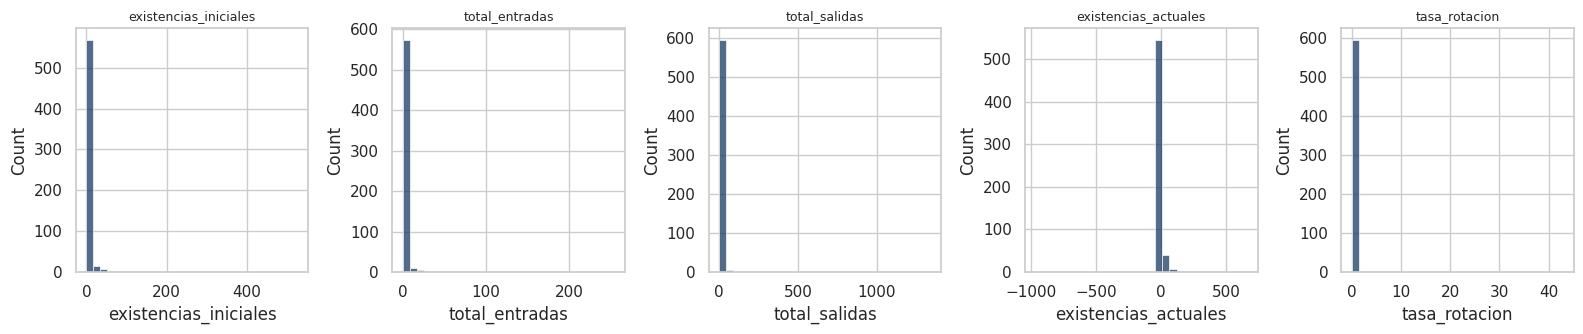

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, col in zip(axes, cols):
    sns.histplot(df_prod[col], bins=30, ax=ax, color='#1b3b64')
    ax.set_title(col, fontsize=9)
plt.tight_layout(); plt.show()

## 6. Boxplots por categoría general

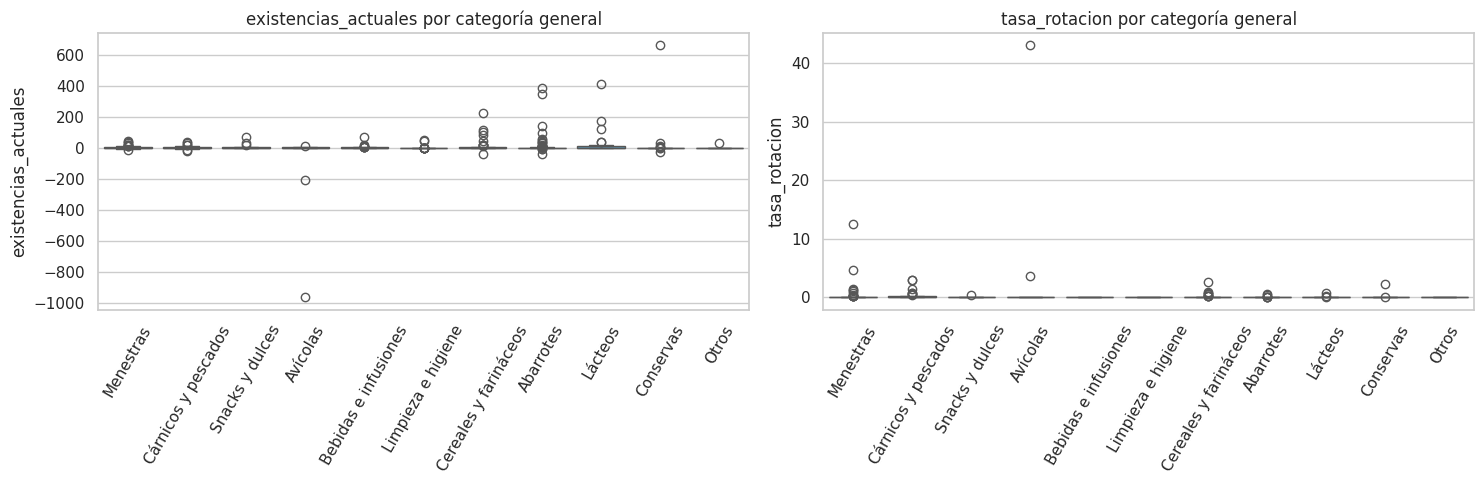

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col in zip(axes, ['existencias_actuales', 'tasa_rotacion']):
    sns.boxplot(data=df_prod, x='categoria_general', y=col, ax=ax, color='#4da9d4')
    ax.tick_params(axis='x', rotation=60)
    ax.set_title(f'{col} por categoría general')
    ax.set_xlabel('')
plt.tight_layout(); plt.show()

## 7. Detección de outliers (IQR)

In [12]:
resultados = []
for col in cols:
    q1, q3 = df_prod[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_prod[col] < q1 - 1.5 * iqr) | (df_prod[col] > q3 + 1.5 * iqr)).sum()
    resultados.append({'variable': col, 'outliers': int(n_out),
                       'pct': round(100 * n_out / len(df_prod), 1)})
pd.DataFrame(resultados)

,variable,outliers,pct
0,existencias_iniciales,127,21.1
1,total_entradas,110,18.2
2,total_salidas,59,9.8
3,existencias_actuales,87,14.4
4,tasa_rotacion,49,8.1


## 8. Balance de las clases objetivo (alertas de stock)

Alerta 7 días : {1: 0.724, 0: 0.276}
Alerta 14 días: {1: 0.722, 0: 0.278}


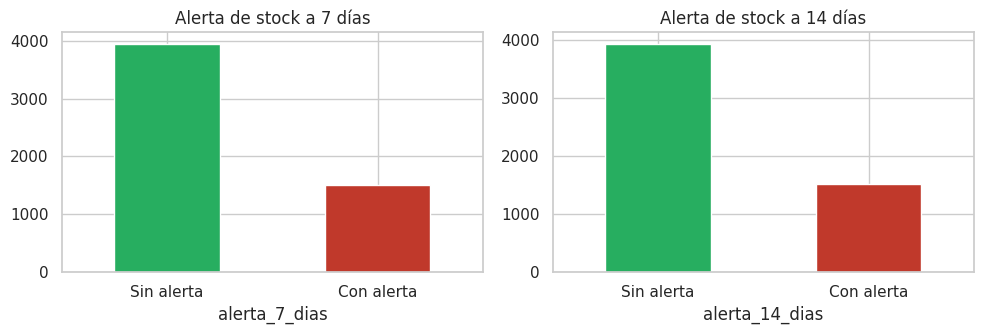

In [13]:
print('Alerta 7 días :', df_sem['alerta_7_dias'].value_counts(normalize=True).round(3).to_dict())
print('Alerta 14 días:', df_sem['alerta_14_dias'].value_counts(normalize=True).round(3).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col, titulo in zip(axes, ['alerta_7_dias', 'alerta_14_dias'],
                           ['Alerta de stock a 7 días', 'Alerta de stock a 14 días']):
    df_sem[col].value_counts().plot.bar(ax=ax, color=['#27ae60', '#c0392b'])
    ax.set_title(titulo); ax.set_xticklabels(['Sin alerta', 'Con alerta'], rotation=0)
plt.tight_layout(); plt.show()

## 9. Evolución semanal del stock por categoría general

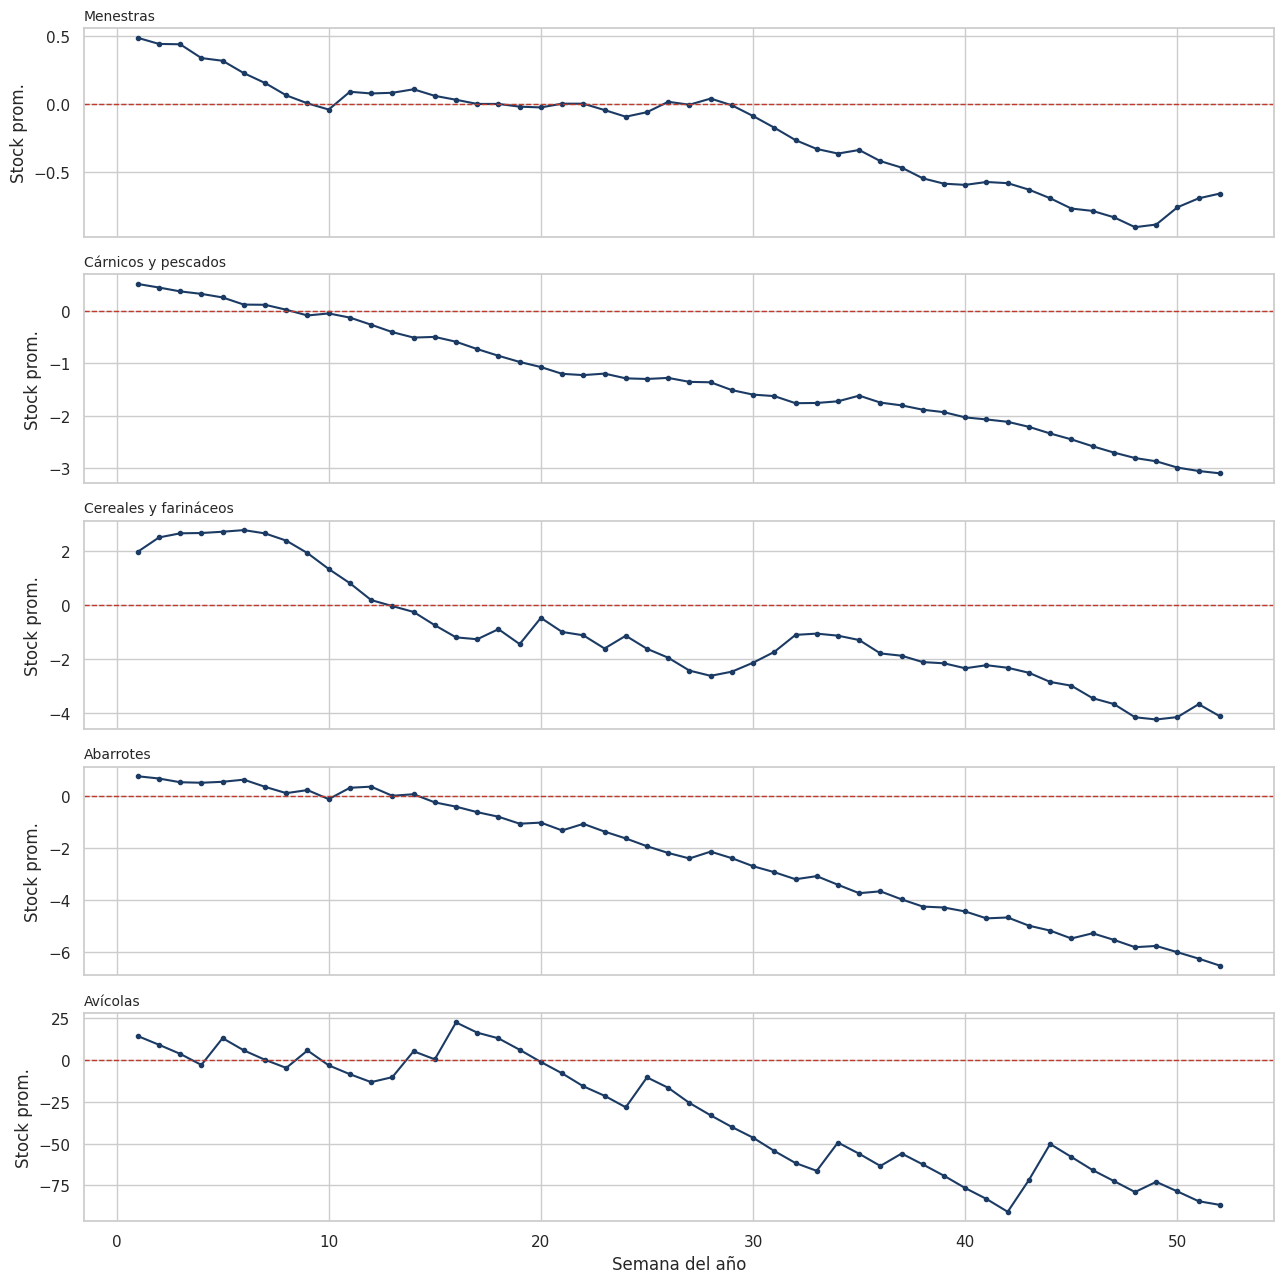

In [14]:
sem_prod = df_sem[df_sem['es_producto'].astype(bool)]
top_cats = sem_prod['categoria_general'].value_counts().head(5).index

fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True)
for ax, cat in zip(axes, top_cats):
    sub = (sem_prod[sem_prod['categoria_general'] == cat]
           .groupby('semana_del_año')['stock_fin_semana'].mean())
    ax.plot(sub.index, sub.values, color='#1b3b64', marker='o', ms=3)
    ax.axhline(0, color='#c0392b', ls='--', lw=1)
    ax.set_ylabel('Stock prom.'); ax.set_title(cat, fontsize=10, loc='left')
axes[-1].set_xlabel('Semana del año')
plt.tight_layout(); plt.show()

## 10. Correlaciones

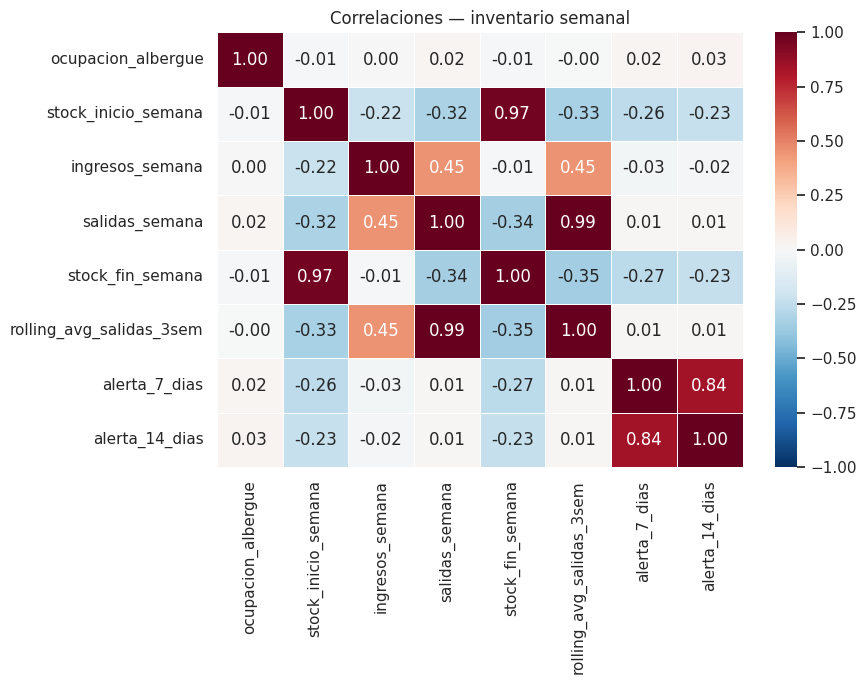

In [15]:
cols_corr = ['ocupacion_albergue', 'stock_inicio_semana', 'ingresos_semana',
             'salidas_semana', 'stock_fin_semana', 'rolling_avg_salidas_3sem',
             'alerta_7_dias', 'alerta_14_dias']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_sem[cols_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlaciones — inventario semanal')
plt.tight_layout(); plt.show()

## 11. Separabilidad de clases

¿Se distinguen las semanas con alerta de las semanas sin alerta según el stock
al inicio de la semana? Esto anticipa qué tan aprendible es el problema.

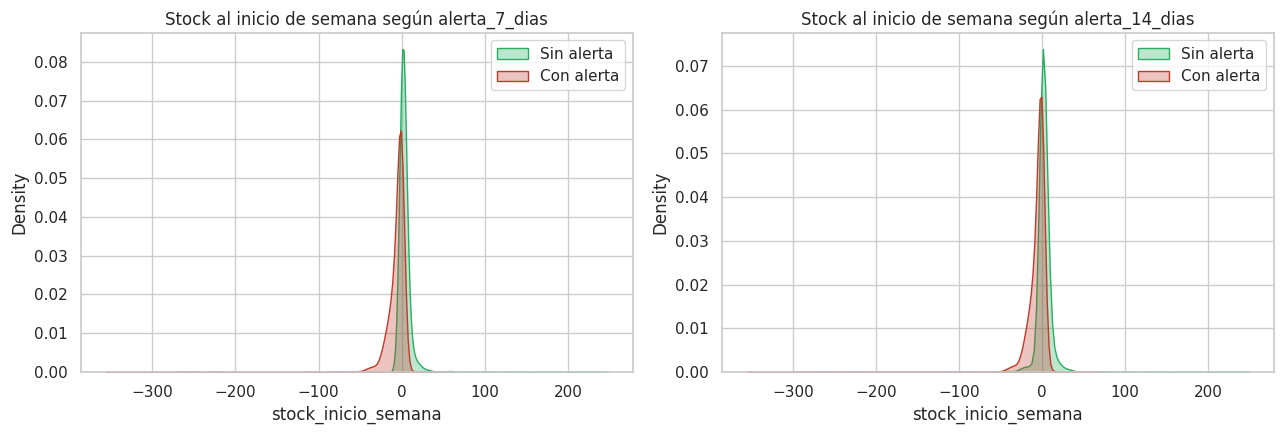

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ['alerta_7_dias', 'alerta_14_dias']):
    for val, label, color in [(0, 'Sin alerta', '#27ae60'), (1, 'Con alerta', '#c0392b')]:
        sub = df_sem[df_sem[col] == val]['stock_inicio_semana']
        sns.kdeplot(sub, ax=ax, label=label, color=color, fill=True, alpha=0.3)
    ax.set_title(f'Stock al inicio de semana según {col}')
    ax.legend()
plt.tight_layout(); plt.show()

## Conclusiones

1. El almacén tiene **602 productos reales** con nombre, presentación y unidad de medida
   estándar; los códigos restantes son registros técnicos que solo se usan para entrenar.
2. Las **11 categorías generales** concentran el inventario en Abarrotes, Limpieza e
   higiene, Menestras y Cereales y farináceos.
3. Las variables de stock presentan fuerte asimetría positiva y outliers propios de un
   almacén de donaciones (ingresos irregulares).
4. Las clases de alerta están desbalanceadas, lo que justifica el uso de métricas F1/AUC
   y el manejo de desbalanceo en el entrenamiento.
5. El stock al inicio de la semana y el consumo promedio móvil separan bien las semanas
   con y sin alerta: buena señal para los modelos de 7 y 14 días.